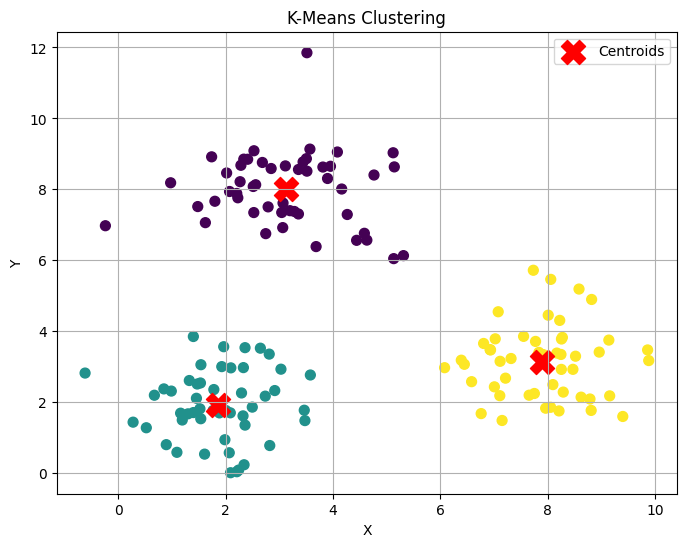

In [1]:
# BÀI 1: CÀI ĐẶT THUẬT TOÁN K-MEANS
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

X1 = np.random.randn(50, 2) + [2, 2]
X2 = np.random.randn(50, 2) + [8, 3]
X3 = np.random.randn(50, 2) + [3, 8]

X = np.vstack((X1, X2, X3))
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))
class KMeansCustom:
    def __init__(self, k=3, max_iters=100):
        self.k = k
        self.max_iters = max_iters

    def fit(self, X):
        random_idx = np.random.choice(len(X), self.k, replace=False)
        self.centroids = X[random_idx]

        for iteration in range(self.max_iters):
            clusters = [[] for _ in range(self.k)]

            for point in X:
                distances = [euclidean_distance(point, centroid)
                             for centroid in self.centroids]

                cluster_index = np.argmin(distances)
                clusters[cluster_index].append(point)

            old_centroids = self.centroids.copy()

            for idx, cluster in enumerate(clusters):
                if len(cluster) > 0:
                    self.centroids[idx] = np.mean(cluster, axis=0)

            if np.all(old_centroids == self.centroids):
                break

        self.labels = []

        for point in X:
            distances = [euclidean_distance(point, centroid)
                         for centroid in self.centroids]

            cluster_index = np.argmin(distances)
            self.labels.append(cluster_index)

        self.labels = np.array(self.labels)

model = KMeansCustom(k=3)
model.fit(X)

plt.figure(figsize=(8,6))

plt.scatter(X[:,0], X[:,1],
            c=model.labels,
            cmap='viridis',
            s=50)

plt.scatter(model.centroids[:,0],
            model.centroids[:,1],
            color='red',
            marker='X',
            s=300,
            label='Centroids')

plt.title("K-Means Clustering")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)

plt.show()

In [2]:
# BÀI 2: CÀI ĐẶT THUẬT TOÁN K-NN
# 2 CÁCH ĐÁNH GIÁ TRỌNG SỐ

import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

class KNNCustom:

    def __init__(self, k=3, weighted=False):
        self.k = k
        self.weighted = weighted

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_test):

        predictions = []

        for test_point in X_test:

            distances = []

            for i, train_point in enumerate(self.X_train):

                dist = euclidean_distance(test_point, train_point)

                distances.append((dist, self.y_train[i]))

            distances.sort(key=lambda x: x[0])

            k_neighbors = distances[:self.k]

            if not self.weighted:

                labels = [label for _, label in k_neighbors]

                prediction = Counter(labels).most_common(1)[0][0]

            else:

                class_weights = {}

                for dist, label in k_neighbors:

                    weight = 1 / (dist + 1e-5)

                    if label not in class_weights:
                        class_weights[label] = 0

                    class_weights[label] += weight

                prediction = max(class_weights,
                                 key=class_weights.get)

            predictions.append(prediction)

        return np.array(predictions)

knn_normal = KNNCustom(k=5, weighted=False)

knn_normal.fit(X_train, y_train)

y_pred_normal = knn_normal.predict(X_test)

acc_normal = accuracy_score(y_test, y_pred_normal)

print("Độ chính xác KNN thường:", acc_normal)

knn_weighted = KNNCustom(k=5, weighted=True)

knn_weighted.fit(X_train, y_train)

y_pred_weighted = knn_weighted.predict(X_test)

acc_weighted = accuracy_score(y_test, y_pred_weighted)

print("Độ chính xác KNN có trọng số:", acc_weighted)

Độ chính xác KNN thường: 1.0
Độ chính xác KNN có trọng số: 1.0


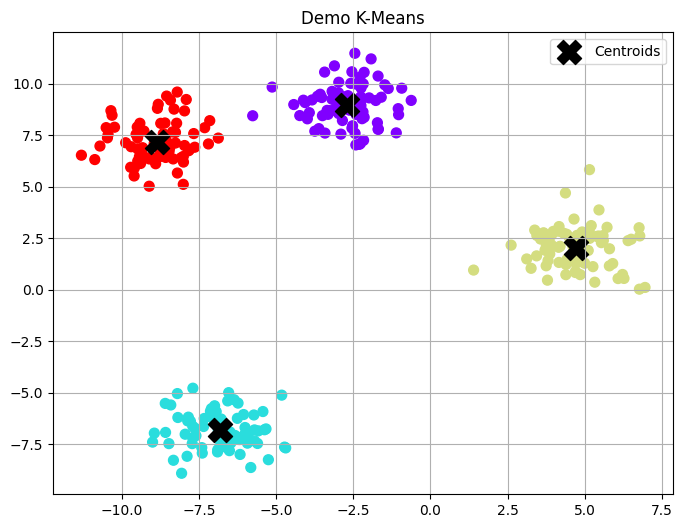

Độ chính xác KNN: 1.0
Dự đoán lớp cho mẫu mới: 0


In [3]:
# BÀI 3: ỨNG DỤNG DEMO K-MEANS VÀ K-NN

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, load_iris
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
# PHẦN 1: DEMO K-MEANS
X, y = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=1.0,
    random_state=42
)
kmeans = KMeans(n_clusters=4, random_state=42)

labels = kmeans.fit_predict(X)

plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=labels,
    cmap='rainbow',
    s=50
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color='black',
    marker='X',
    s=300,
    label='Centroids'
)

plt.title("Demo K-Means")
plt.legend()
plt.grid(True)

plt.show()

# PHẦN 2: DEMO K-NN

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Độ chính xác KNN:", accuracy)

sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = knn.predict(sample)

print("Dự đoán lớp cho mẫu mới:", prediction[0])